# Spaceship Titanic: Ensemble Models

The goal of this project is to predict whether a passenger
was transported to another dimension using demographic,
travel and spending features.

The project focuses on:
- exploratory data analysis;
- categorical feature preprocessing;
- decision trees and ensemble models;
- feature importance;
- hyperparameter analysis;
- robustness to missing values and outliers.

# Imports and configuration

In [36]:
# Библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from pandas.api.types import is_datetime64_any_dtype, is_string_dtype, is_numeric_dtype, is_categorical_dtype

# Data loading

In [15]:
data = pd.read_csv('train.csv')

In [16]:
data.head(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False


In [17]:
X = data.drop(['PassengerId', 'Transported'], axis=1)
y = data['Transported'].astype(int)

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=13, stratify=y_temp)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 6085, Val: 1304, Test: 1304


In [19]:
data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [20]:
print(f"Количество объектов: {X_train.shape[0]}")
print(f"Количество признаков: {X_train.shape[1]}")

Количество объектов: 6085
Количество признаков: 12


In [22]:
# Можно убрать еще Cabin, Name - бесполезная информация
X_train = X_train.drop(['Name'], axis=1)
X_val = X_val.drop(['Name'], axis=1)
X_test = X_test.drop(['Name'], axis=1)

In [23]:
# Количество пропусков
X_train.isna().sum()

HomePlanet      147
CryoSleep       155
Cabin           139
Destination     130
Age             127
VIP             142
RoomService     114
FoodCourt       124
ShoppingMall    156
Spa             127
VRDeck          129
dtype: int64

In [24]:
# Смотрим статистики по датасету
X_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,5958.000000,5971.000000,5961.000000,5929.000000,5958.000000,5956.000000
mean,29.114804,231.900017,445.455293,175.825603,309.839543,304.769644
std,14.654132,683.734295,1585.487489,619.507349,1148.414711,1141.452833
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,49.500000,68.000000,24.000000,59.000000,45.250000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,20336.000000


In [25]:
# Ищем намеки на категориальные колонки
X_train.nunique()

HomePlanet         3
CryoSleep          2
Cabin           4883
Destination        3
Age               80
VIP                2
RoomService     1048
FoodCourt       1166
ShoppingMall     914
Spa             1060
VRDeck          1041
dtype: int64

# 5. Exploratory Data Analysis

<Axes: xlabel='Transported'>

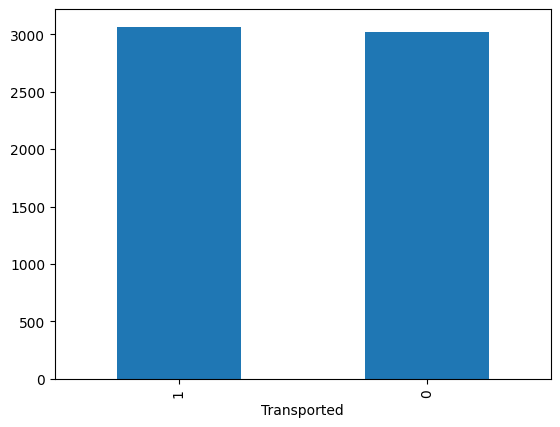

In [30]:
# Смотрим на сбалансированность классов
y_train.value_counts().plot(kind='bar')

In [31]:
train_df = X_train.copy()
train_df['Transported'] = y_train.values

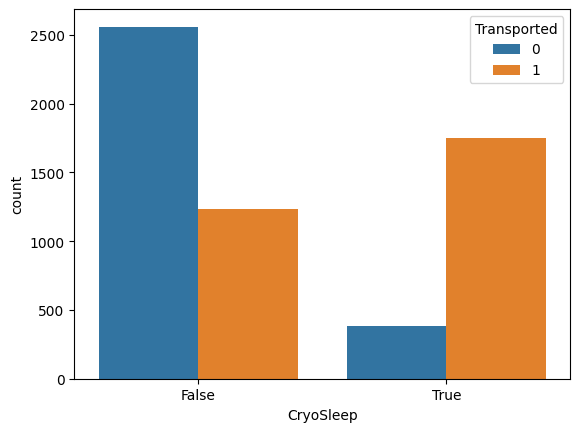

In [32]:
# Есть подозрение, что CryoSleep и Transported коррелируют
sns.countplot(data=train_df, x='CryoSleep', hue='Transported')
plt.show()

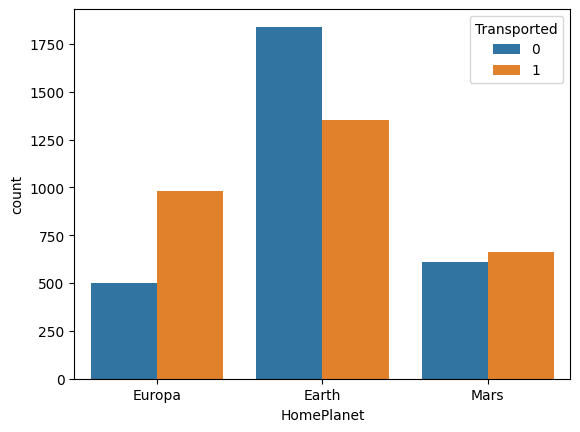

In [33]:
# Интересно, с какой планеты люди чаще долетали до точки назначения
sns.countplot(data=train_df, x='HomePlanet', hue='Transported')
plt.show()

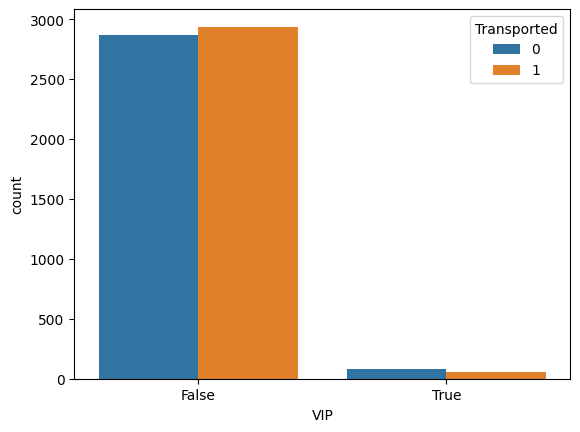

In [34]:
# Коррелирует ли VIP с Transported (как на Титанике) 
sns.countplot(data=train_df, x='VIP', hue='Transported')
plt.show()

Text(0.5, 0, 'VRDeck')

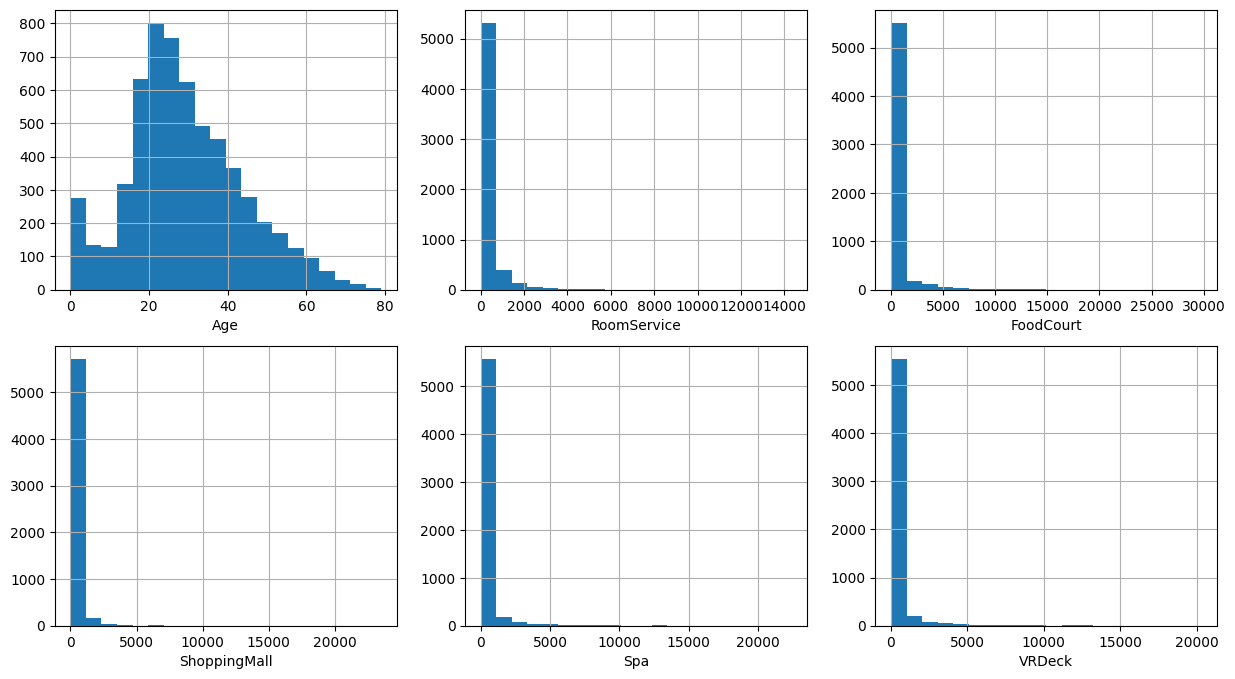

In [35]:
# Посмотрим на непрерывные признаки

plt.figure(figsize=(15,8))
plt.subplot(2, 3, 1)
fig = X_train.Age.hist(bins=20)
fig.set_xlabel('Age')

plt.subplot(2, 3, 2)
fig = X_train.RoomService.hist(bins=20)
fig.set_xlabel('RoomService')

plt.subplot(2, 3, 3)
fig = X_train.FoodCourt.hist(bins=20)
fig.set_xlabel('FoodCourt')

plt.subplot(2, 3, 4)
fig = X_train.ShoppingMall.hist(bins=20)
fig.set_xlabel('ShoppingMall')

plt.subplot(2, 3, 5)
fig = X_train.Spa.hist(bins=20)
fig.set_xlabel('Spa')

plt.subplot(2, 3, 6)
fig = X_train.VRDeck.hist(bins=20)
fig.set_xlabel('VRDeck')

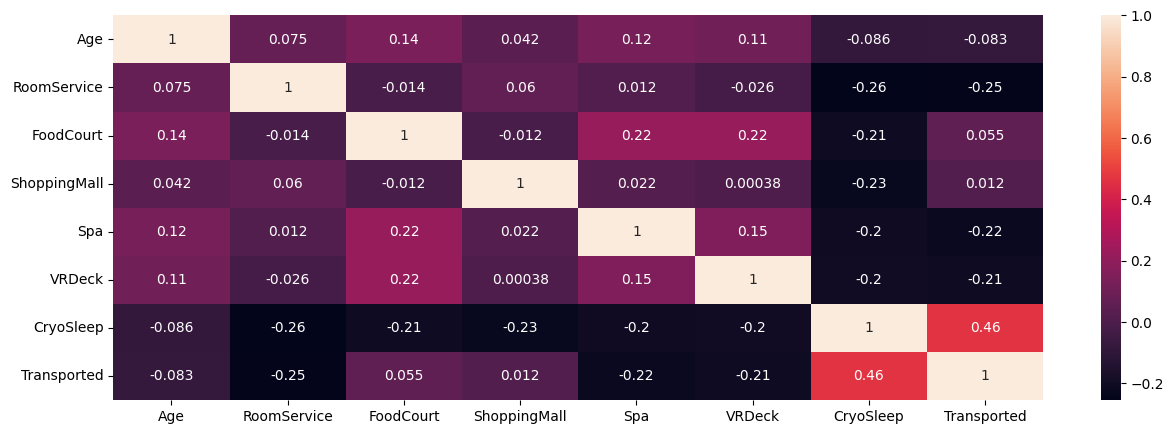

In [79]:
# Посмотрим на корреляционную матрицу
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'Transported']
correlation_matrix = data[numeric_cols].corr()
plt.figure(figsize=(15,5))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

# Feature preprocessing

In [38]:
def split_cabin(df):
    df = df.copy()
    parts = df['Cabin'].str.split('/', expand=True)
    df['Cabin_first']  = parts[0]
    df['Cabin_number'] = pd.to_numeric(parts[1], errors='coerce')
    df['Cabin_last']   = parts[2]
    return df.drop(columns=['Cabin'])

X_train = split_cabin(X_train)
X_val   = split_cabin(X_val)
X_test  = split_cabin(X_test)

In [39]:
spend_cols   = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
other_num    = ['Age', 'Cabin_number']
num_features = spend_cols + other_num
cat_features = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP',
                'Cabin_first', 'Cabin_last']

# log1p только на тратах; StandardScaler уже после — чтобы не сломать распределение
spend_transformer = Pipeline(steps=[
    ('log',     FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

other_num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('spend', spend_transformer,       spend_cols),
    ('num',   other_num_transformer,   other_num),
    ('cat',   cat_transformer,         cat_features),
])

# fit только на train, transform на всех
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

In [51]:
feature_names = preprocessor.get_feature_names_out()
print(len(feature_names), feature_names[:10])

27 ['spend__RoomService' 'spend__FoodCourt' 'spend__ShoppingMall'
 'spend__Spa' 'spend__VRDeck' 'num__Age' 'num__Cabin_number'
 'cat__HomePlanet_Earth' 'cat__HomePlanet_Europa' 'cat__HomePlanet_Mars']


# Model comparison

In [41]:
def best_parameters(X_train, y_train, X_val, y_val, param_name, parameters, model, ver=True):
    """
    Подбирает лучший параметр для модели
    
    Parameters:
    - X_train, y_train: обучающие данные
    - X_val, y_val: валидационные данные
    - param_name: имя параметра (строка), например 'n_estimators' или 'max_depth'
    - parameters: список значений параметра для перебора
    - model: класс модели (например, RandomForestClassifier)
    
    Returns:
    - лучшее значение параметра
    """
    
    
    train_scores = []
    val_scores = []

    f1_train_scores = []
    f1_val_scores = []


    for par in parameters:
        if (ver==True):
            params = {param_name: par, 'random_state': 13}

        else:
            params = {param_name: par, 'random_state': 13, 'verbose': False}
        mod = model(**params)
        mod.fit(X_train, y_train)
    
        train_scores.append(mod.score(X_train, y_train))
        val_scores.append(mod.score(X_val, y_val))
        f1_val_scores.append(f1_score(y_val, mod.predict(X_val)))
        f1_train_scores.append(f1_score(y_train, mod.predict(X_train)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(parameters, train_scores, label='Train')
    ax1.plot(parameters, val_scores, label='Validation')
    ax1.set_xlabel(f'{param_name}')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График F1-score
    ax2.plot(parameters, f1_train_scores, label='Train F1')
    ax2.plot(parameters, f1_val_scores, label='Validation F1')
    ax2.set_xlabel(f'{param_name}')
    ax2.set_ylabel('F1-score')
    ax2.set_title('F1-score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f'Best {param_name} = {parameters[np.argmax(val_scores)]}')
    
    return parameters[np.argmax(val_scores)]

1. Decision tree

Accuracy: 73.85%
F1-score: 73.87%

Confusion Matrix:


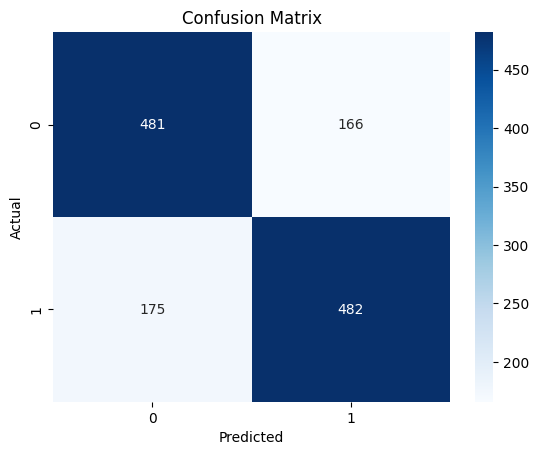

In [43]:
# Попробуем без подбора параметров

model = DecisionTreeClassifier(criterion="entropy", random_state=13)  
model.fit(X_train_prep, y_train)    
y_pred = model.predict(X_test_prep)  
accuracy_ct = accuracy_score(y_test, y_pred)
f1_ct = f1_score(y_test, y_pred)
print(f'Accuracy: {100*accuracy_ct:.2f}%')
print(f'F1-score: {100*f1_ct:.2f}%')


print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

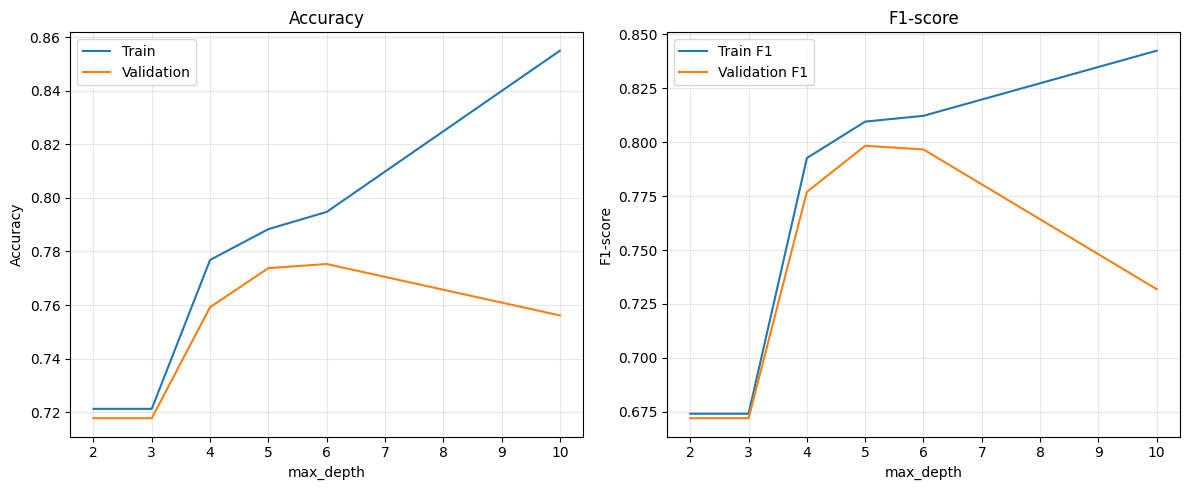

Best max_depth = 6
Лучшая глубина: 6
Test accuracy: 75.46%
F1-score: 77.6224%


In [47]:
# Подбираем max_depth
max_depth = best_parameters(
    X_train_prep, y_train, 
    X_val_prep, y_val, 
    param_name = 'max_depth', 
    parameters = [2, 3, 4, 5, 6, 10], 
    model = DecisionTreeClassifier
)

final_ct_model = DecisionTreeClassifier(max_depth=max_depth, random_state=13)
final_ct_model.fit(X_train_prep, y_train)           
accuracy_best_ct = final_ct_model.score(X_test_prep, y_test)
y_pred = final_ct_model.predict(X_test_prep)
f1_best_ct = f1_score(y_test, y_pred)

print(f'Лучшая глубина: {max_depth}')
print(f'Test accuracy: {100*accuracy_best_ct:.2f}%')
print(f'F1-score: {100*f1_best_ct:.4f}%')

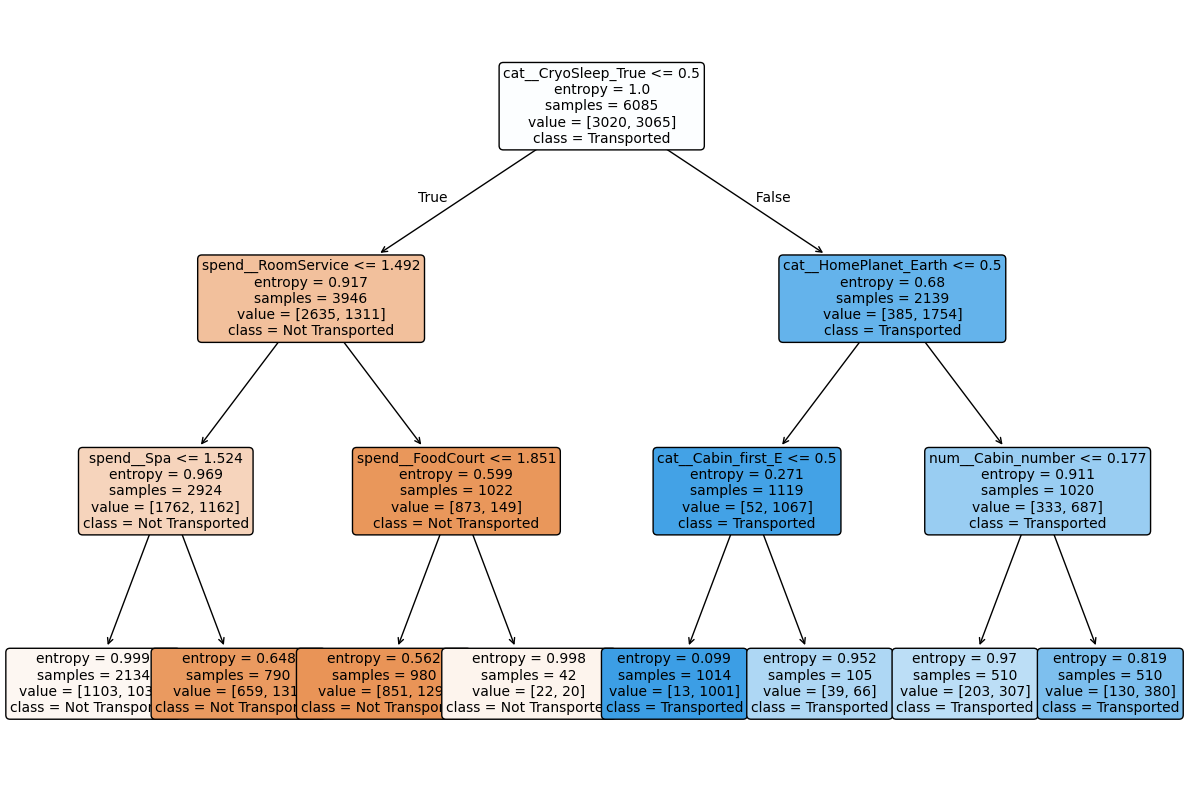

In [52]:
# Интереса ради визуализируем дерево
vis_model = DecisionTreeClassifier(criterion="entropy", max_depth=3,  min_samples_split=5, random_state=13)
vis_model.fit(X_train_prep, y_train)

plt.figure(figsize=(15,10))
plot_tree(
    vis_model,
    feature_names=feature_names,
    class_names=['Not Transported', 'Transported'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [53]:
print("Сравнение моделей для случайного дерева: \n")
print(f'CT: acc = {100*accuracy_ct:.2f}%, f1 = {100*f1_ct:.2f}%')
print(f'CT + max_depth: acc = {100*accuracy_best_ct:.2f}%, f1 = {100*f1_best_ct:.2f}%')

Сравнение моделей для случайного дерева: 

CT: acc = 73.85%, f1 = 73.87%
CT + max_depth: acc = 75.46%, f1 = 77.62%


2. Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

Accuracy:  78.53%
F1-score:  77.78%


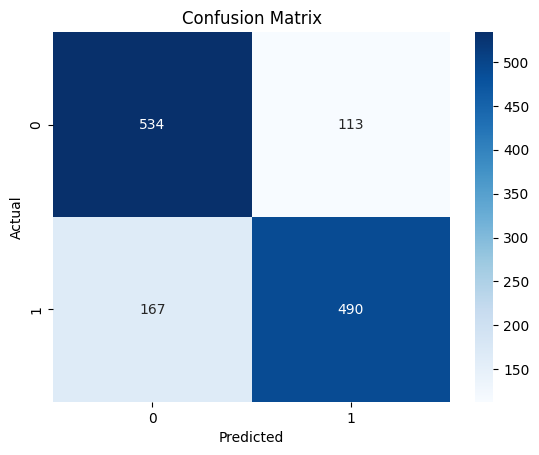

In [55]:
# Обучаем Random Forest без подбора параметров
rf_model = RandomForestClassifier(random_state=13)
rf_model.fit(X_train_prep, y_train)

y_pred = rf_model.predict(X_test_prep)
accuracy_rf = accuracy_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print(f'Accuracy:  {100*accuracy_rf:.2f}%')
print(f'F1-score:  {100*f1_rf:.2f}%')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
# Получаем важность признаков
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(5))

              feature  importance
6   num__Cabin_number    0.175417
5            num__Age    0.135213
3          spend__Spa    0.098027
0  spend__RoomService    0.092945
4       spend__VRDeck    0.087168


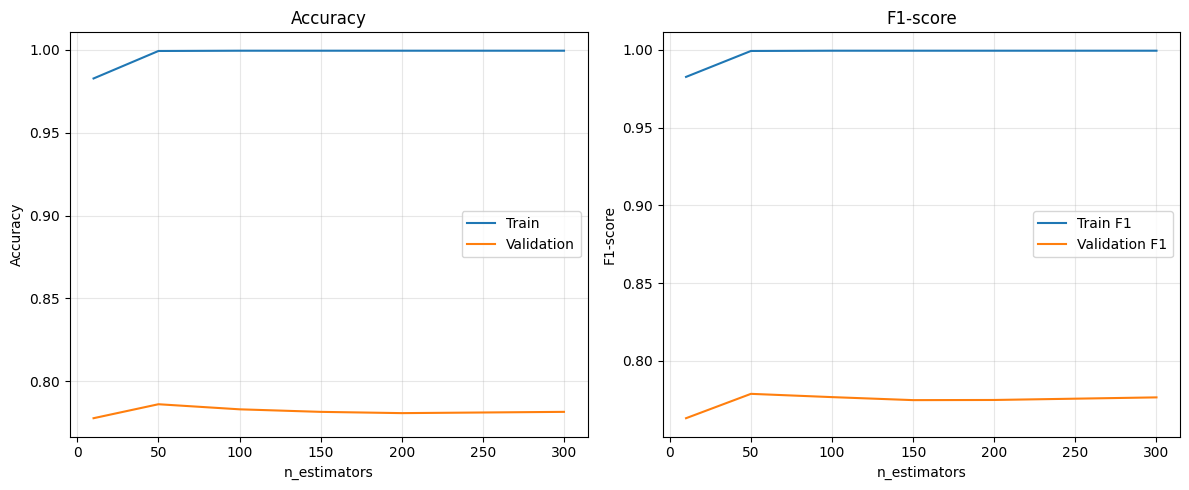

Best n_estimators = 50


In [57]:
# Подбираем число деревьев
n_est = best_parameters(
    X_train_prep, y_train, 
    X_val_prep, y_val, 
    param_name='n_estimators', 
    parameters = [10, 50, 100, 150, 200, 300], 
    model = RandomForestClassifier
)

In [58]:
temp_model = RandomForestClassifier(n_estimators=n_est, random_state=13)
temp_model.fit(X_train_prep, y_train)           
accuracy_temp_rf = temp_model.score(X_test_prep, y_test)
y_pred = temp_model.predict(X_test_prep)
f1_temp_rf = f1_score(y_test, y_pred)

print(f'Лучшая глубина: {n_est}')
print(f'Test accuracy: {100*accuracy_temp_rf:.2f}%')
print(f'Test F1-score: {100*f1_temp_rf:.4f}%')

importances = temp_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nТоп-5 самых важных признаков:")
print(importance_df.head(5))

Лучшая глубина: 50
Test accuracy: 78.37%
Test F1-score: 77.6899%

Топ-5 самых важных признаков:
              feature  importance
6   num__Cabin_number    0.176485
5            num__Age    0.134728
3          spend__Spa    0.098800
0  spend__RoomService    0.091840
4       spend__VRDeck    0.081425


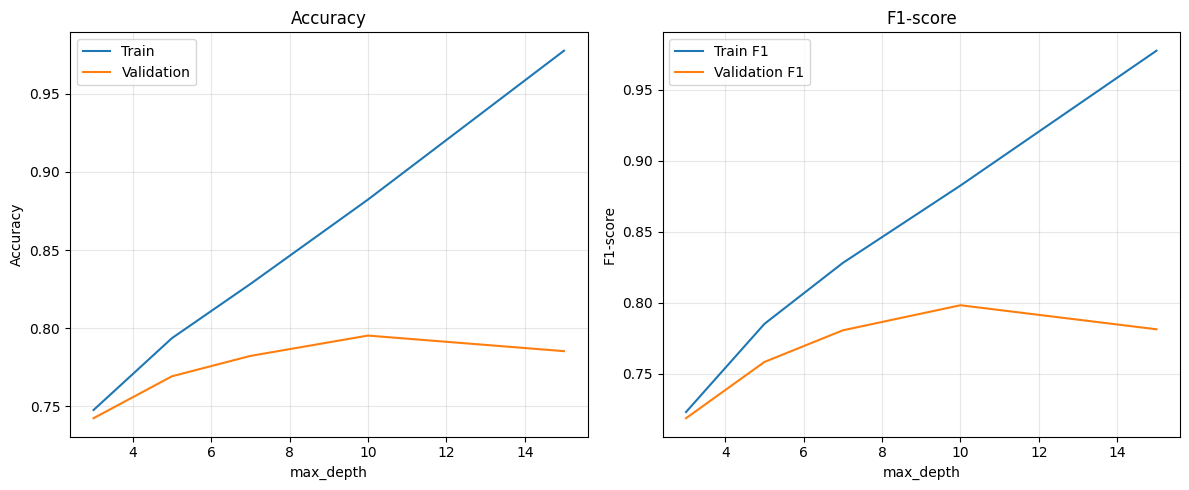

Best max_depth = 10


In [59]:
# Подбираем глубину деревьев
max_depth_RF = best_parameters(
    X_train_prep, y_train, 
    X_val_prep, y_val, 
    param_name='max_depth', 
    parameters = [3, 5, 7, 10, 15, None], 
    model = RandomForestClassifier
)

In [60]:
final_model = RandomForestClassifier(n_estimators=n_est, max_depth = max_depth_RF, random_state=13)
final_model.fit(X_train_prep, y_train)           
accuracy_best_rf = final_model.score(X_test_prep, y_test)
y_pred = final_model.predict(X_test_prep)
f1_best_rf = f1_score(y_test, y_pred)

print(f'Test accuracy: {100*accuracy_best_rf:.2f}%')
print(f'Test F1-score: {100*f1_best_rf:.4f}%')

importances = final_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nТоп-5 самых важных признаков:")
print(importance_df.head(5))

Test accuracy: 78.76%
Test F1-score: 78.5770%

Топ-5 самых важных признаков:
                 feature  importance
3             spend__Spa    0.123806
14   cat__CryoSleep_True    0.113587
0     spend__RoomService    0.102788
4          spend__VRDeck    0.098451
13  cat__CryoSleep_False    0.097372


In [61]:
print("Сравнение моделей для случайного леса: \n")
print(f'RF: acc = {100*accuracy_rf:.2f}%, f1 = {100*f1_rf:.2f}%')
print(f'RF + n_est: acc = {100*accuracy_temp_rf:.2f}%, f1 = {100*f1_temp_rf:.2f}%')
print(f'RF + n_est + max_depth: acc = {100*accuracy_best_rf:.2f}%, f1 = {100*f1_best_rf:.2f}%')

Сравнение моделей для случайного леса: 

RF: acc = 78.53%, f1 = 77.78%
RF + n_est: acc = 78.37%, f1 = 77.69%
RF + n_est + max_depth: acc = 78.76%, f1 = 78.58%


3. CatBoost

In [62]:
from catboost import CatBoostClassifier

Accuracy:  80.14%
F1-score:  80.18%


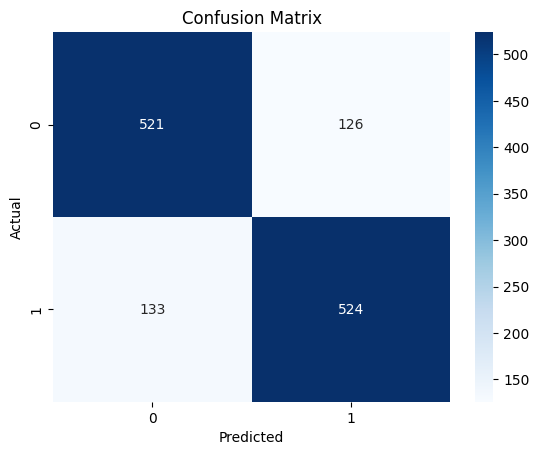

In [63]:
# Без настройки параметров
cb = CatBoostClassifier(random_seed=13, verbose=False)
cb.fit(X_train_prep, y_train)

y_pred = cb.predict(X_test_prep)
accuracy_cb = accuracy_score(y_test, y_pred)
f1_cb = f1_score(y_test, y_pred)

print(f'Accuracy:  {100*accuracy_cb:.2f}%')
print(f'F1-score:  {100*f1_cb:.2f}%')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

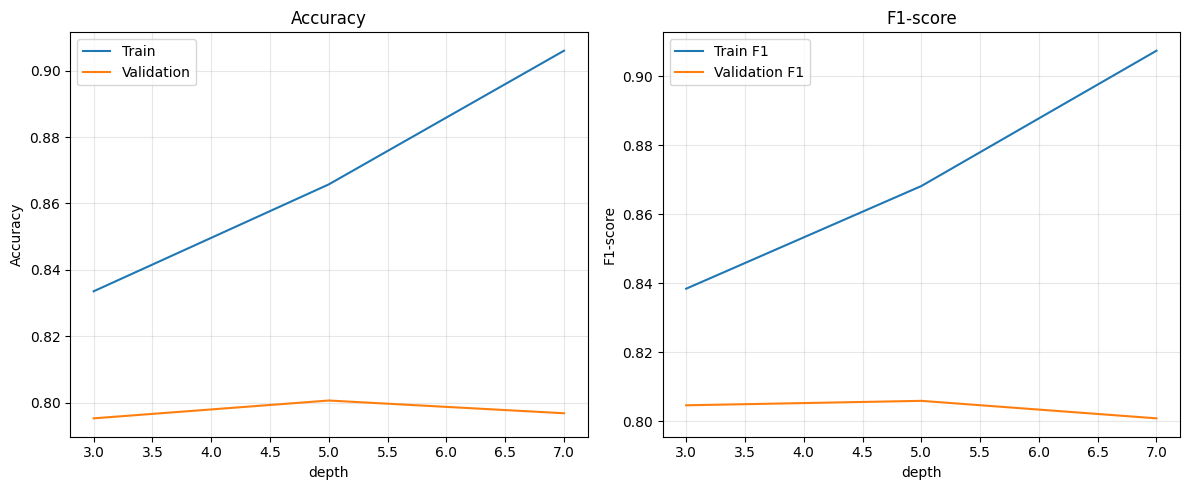

Best depth = 5
Test accuracy: 80.06%
Test F1-score: 80.1527%


In [64]:
# Подбираем глубину деревьев
opt_depth = best_parameters(
    X_train_prep, y_train, 
    X_val_prep, y_val, 
    param_name='depth', 
    parameters = [3, 5, 7], 
    model = CatBoostClassifier,
    ver=False
)

best_model = CatBoostClassifier(depth=opt_depth, random_state=13, verbose = False)
best_model.fit(X_train_prep, y_train)           
accuracy_best_cb = best_model.score(X_test_prep, y_test)
y_pred = best_model.predict(X_test_prep)
f1_best_cb = f1_score(y_test, y_pred)

print(f'Test accuracy: {100*accuracy_best_cb:.2f}%')
print(f'Test F1-score: {100*f1_best_cb:.4f}%')

In [65]:
print("Сравнение моделей: \n")
print(f'Random Tree: acc = {100*accuracy_best_ct:.2f}%, f1 = {100*f1_best_ct:.2f}%')
print(f'Random Forest: acc = {100*accuracy_best_rf:.2f}%, f1 = {100*f1_best_rf:.2f}%')
print(f'CatBoost: acc = {100*accuracy_best_cb:.2f}%, f1 = {100*f1_best_cb:.2f}%')

Сравнение моделей: 

Random Tree: acc = 75.46%, f1 = 77.62%
Random Forest: acc = 78.76%, f1 = 78.58%
CatBoost: acc = 80.06%, f1 = 80.15%


## Conclusions

- Decision Tree achieved a test accuracy of Accuracy = 0.755, F1-score = 0.776.
- Random Forest improved performance through ensembling.
- CatBoost achieved the best performance:
  Accuracy = 0.801
  F1-score = 0.801.
- Log transformation improved the representation of highly skewed
  spending features.
- Cabin decomposition provided useful additional features.
- Increasing the number of shallow trees beyond several hundred
  produced little additional improvement.